This notebook produces Figures 16-17, which plots the percent non-vegetated ground (NVG) pixels at different thresholds of coherence using methods 1 and 2. Figure 16 is for the whole ROI, Figure 17 is for individual focus areas (A-E).
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [1]:
#import necessary packages
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
%matplotlib  widget

In [2]:
# load in road mask and no_desert mask to separate surface types 

# these masks sit in the folder for Figure 3
load_file = '../Figure_3_surface_types_map/'

f1 = gdal.Open(load_file+'roadarray.r4', gdal.GA_ReadOnly)
NVG_mask = f1.ReadAsArray()   #this should only contain 1s and 0s
f1 = None

f1 = gdal.Open(load_file+'no_desert.r4', gdal.GA_ReadOnly)
no_desert = f1.ReadAsArray()   #this should only contain 1s and 0s
f1 = None
# the file is actually flipped from what is intuitive, so flipping the 1's and 0's here.
no_desert = np.where(no_desert==1,0,1) # the 1's are now the non-desert pixels 

# create a mask where desert and vegetated pixels=0, and urban pixels=1
updated_roads = no_desert * NVG_mask+1
no_desert_mask = np.where(updated_roads==2,1,0)

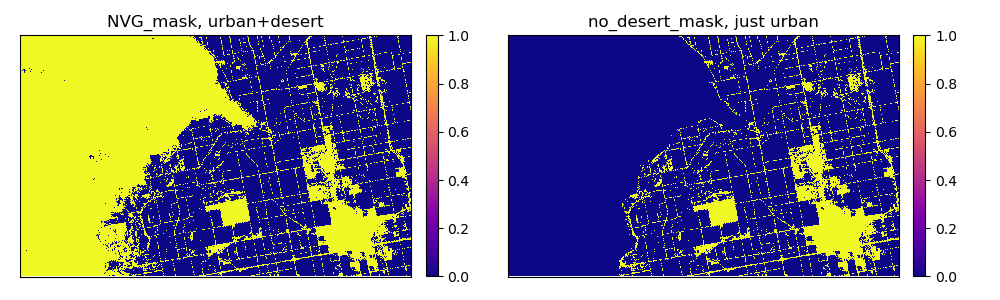

In [3]:
# plot the masks, make sure they look right.
plt.figure(figsize=(10,3),tight_layout=True)
plt.subplot(1,2,1)
plt.imshow(NVG_mask,aspect='auto',interpolation='none')
plt.colorbar(pad=0.03); plt.set_cmap('plasma')
plt.xlim(9000,0); plt.ylim(1575,0)
plt.xticks([]); plt.yticks([]); plt.title('NVG_mask, urban+desert')
plt.subplot(1,2,2)
plt.imshow(no_desert_mask,aspect='auto',interpolation='none')
plt.colorbar(pad=0.03); plt.set_cmap('plasma')
plt.xlim(9000,0); plt.ylim(1575,0)
plt.xticks([]); plt.yticks([]); plt.title('no_desert_mask, just urban')
plt.show()

In [4]:
# # load average coherence (average gamma1 and average gamma2)
saveDir_avg = '../../2_Calculating_coherence_2_ways/'

fileNameAvg_1 = 'avg_coh_method1.r4'  
f1 = gdal.Open(saveDir_avg + fileNameAvg_1, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m1 = f1.ReadAsArray()
f1 = None

fileNameAvg_2 = 'avg_coh_method2.r4'  
f2 = gdal.Open(saveDir_avg + fileNameAvg_2, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m2 = f2.ReadAsArray()
f2 = None

In [ ]:
# make a function that ingests a mask and calculates the %NVG pixels captured at a series of coherence thresholds
# this is for the entire ROI 

def grab_for_thresholds(mask,desert='False'):
    '''
    mask is the array of 1's and 0's with valid pixels having value of 1
    'valid pixels' refers to the surface type we want; this is either urban, or urban+barren/desert
    '''

    # how many valid pixels in the mask? 
    num_road_pixels = sum(mask)  # changes with mask

    # create a set of coherence magnitude threshold values I want to test
    coh_threshold2_pt1 = np.linspace(0.2,0.7, num=11, endpoint = True)
    coh_threshold2_pt2 = np.linspace(0.7,1, num=12, endpoint = False)
    coh_threshold = np.concatenate((coh_threshold2_pt1,coh_threshold2_pt2))

    # initialize arrays to hold the percent NVG data 
    percent_captured_coh1 = np.zeros(len(coh_threshold),'float')
    percent_captured_coh2 = np.zeros(len(coh_threshold),'float')
    # initialize arrays to sum the total number of pixels that meet a coherence threshold
    total_coh1 = np.zeros(len(coh_threshold),'float')*np.nan
    total_coh2 = np.zeros(len(coh_threshold),'float')*np.nan

    # grab the coherence values where the desired surface type is present, mask everything else 
    m1_avg_road_masked = np.where(mask==1,coh_avg_m1,np.nan)  #changes with mask
    m2_avg_road_masked = np.where(mask==1,coh_avg_m2,np.nan) 

    #determine % NVG pixels captured at each coh threshold
    for c in range (len(coh_threshold)):
        #number of pixels in each coherence image
        coh1_c_masked = np.where(coh_avg_m1 >= coh_threshold[c], 1, np.nan)
        if desert==True:
            # remove desert pixels from the "coherent" num pixels (that meet coh threshold)
            coh1_c_masked[desert==0] = 0.0
        total_coh1[c] = np.nansum(coh1_c_masked)

        # print('Coh threshold: '+str(coh_threshold[c]))
        coh2_c_masked = np.where(coh_avg_m2 >= coh_threshold[c], 1, np.nan)
        if desert==True:
            # remove desert pixels from the "coherent" num pixels (that meet coh threshold)
            coh2_c_masked[desert==0] = 0.0
        total_coh2[c] = np.nansum(coh2_c_masked)

        #number of road pixels captured (in coh image masked by roads)
        road_c_masked_1 = np.where(m1_avg_road_masked >= coh_threshold[c], 1, np.nan)
        total_road_coh1 = np.nansum(road_c_masked_1)
        road_c_masked_2 = np.where(m2_avg_road_masked >= coh_threshold[c], 1, np.nan)
        total_road_coh2 = np.nansum(road_c_masked_2)

        #calculate % NVG pix captured
        if total_coh1[c] > 0:
            percent_captured_coh1[c] = (total_road_coh1/total_coh1[c])*100
            # print('Total numerator: '+str(total_road_coh1))
            # print('Total denominator: '+str(total_coh1))
        else:
            percent_captured_coh1[c] = 0
            # print('No pixels that meet this threshold.')

        if total_coh2[c] > 0:
            percent_captured_coh2[c] = (total_road_coh2/total_coh2[c])*100
            # print('Total numerator: '+str(total_road_coh3))
            # print('Total denominator: '+str(total_coh3))
        else:
            percent_captured_coh2[c] = 0
            # print('No pixels that meet this threshold.')
    return percent_captured_coh1, percent_captured_coh2, total_coh1, total_coh2

In [6]:
# use the same set of coherence magnitude threshold values I want to test
coh_threshold2_pt1 = np.linspace(0.2,0.7, num=11, endpoint = True)
coh_threshold2_pt2 = np.linspace(0.7,1, num=12, endpoint = False)
coh_threshold = np.concatenate((coh_threshold2_pt1,coh_threshold2_pt2))

# run the coherence threshold sequence through the function to calculate % NVG pixels captured at each threshold for each coherence method
# with the desert considered NVG pixels 
percent_capt_coh1_NVG, percent_capt_coh2_NVG, total_coh1_NVG, total_coh2_NVG = grab_for_thresholds(NVG_mask)
# without the desert considered NVG pixels 
percent_capt_coh1_no_desert, percent_capt_coh2_no_desert, total_coh1_no_desert, total_coh2_no_desert = grab_for_thresholds(no_desert_mask,desert=True)

In [7]:
# calculate how many pixels there are in the entire ROI to see what fraction of pixels even meet the coherence threshold 
dx = 9000
dy = 1575
tot_pix_ROI = dx*dy
tot_pix_nondesert = np.sum(no_desert)

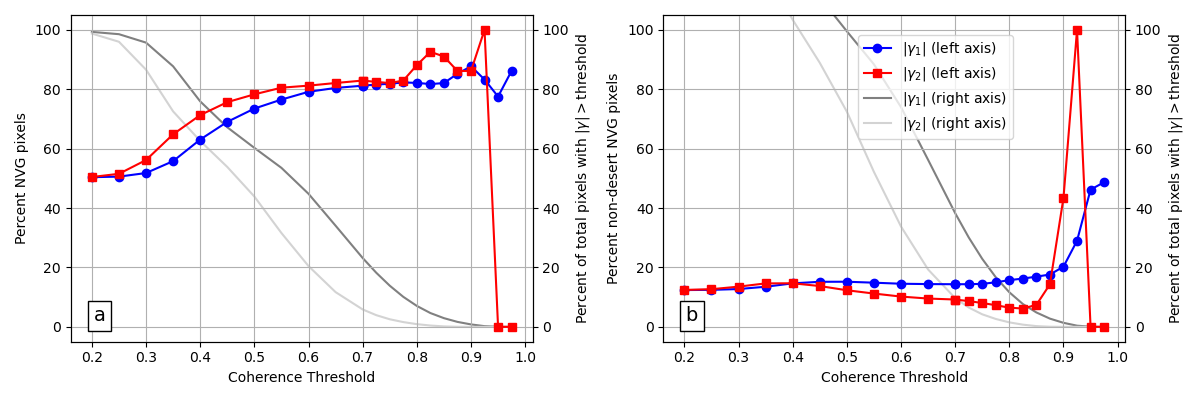

In [8]:
# This is Figure 16.
label_x = 0.075
label_y = 0.05
props = dict(boxstyle='square',facecolor='white',edgecolor='black')
twinx_ylabel = 'Percent of total pixels with $|\gamma|>$threshold'
ylabel = 'Percent NVG pixels'

fig, axs = plt.subplots(1,2,figsize=(12,4),tight_layout=True)
ax = axs[0]
ax.plot(coh_threshold,percent_capt_coh1_NVG,'b-o',label='$|\gamma_{1}|$ (left axis)')
ax.plot(coh_threshold,percent_capt_coh2_NVG,'r-s',label='$|\gamma_{2}|$ (left axis)')
ax.set_xlabel('Coherence Threshold')
ax.set_ylabel(ylabel)
ax.set_ylim(-5,105)  
ax.grid() 
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.set_facecolor('none')
ax1 = ax.twinx()
ax1.plot(coh_threshold,total_coh1_NVG/tot_pix_ROI*100,'gray',linestyle='-',label='$|\gamma_{1}|$ (right axis)')
ax1.plot(coh_threshold,total_coh2_NVG/tot_pix_ROI*100,'lightgray',linestyle='-',label='$|\gamma_{2}|$ (right axis)')
ax1.set_ylabel(twinx_ylabel)
ax1.set_zorder(ax.get_zorder() - 1)
ax1.set_ylim(-5,105)  
# ax1.legend(loc='center')

ax = axs[1]
ax.plot(coh_threshold,percent_capt_coh1_no_desert,'b-o')
ax.plot(coh_threshold,percent_capt_coh2_no_desert,'r-s')
ax.set_xlabel('Coherence Threshold')
ax.set_ylabel('Percent non-desert NVG pixels')  
ax.set_ylim(-5,105)  
ax.grid() 
# ax.legend(loc='center left')
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.set_facecolor('none')
ax1 = ax.twinx()
#ax1.set_yscale('log')
ax1.plot(coh_threshold,total_coh1_no_desert/tot_pix_nondesert*100,'gray',linestyle='-')
ax1.plot(coh_threshold,total_coh2_no_desert/tot_pix_nondesert*100,'lightgray',linestyle='-')
ax1.set_ylabel(twinx_ylabel)
ax1.set_zorder(ax.get_zorder() - 1)
fig.legend(bbox_to_anchor=(0.85,0.93),ncols=1)
ax1.set_ylim(-5,105)  

plt.show()
#plt.savefig('NVGs_captured_all_areas.png',transparent=True,bbox_inches='tight',dpi=500)

In [9]:
# Now compute this, but for the focus areas
imperial_road = [6820, 100, 7520, 450] #A
pools = [7700,300, 8400, 650] #B
transect_roads = [4500, 650, 6600, 1000] #C
imperial_airport = [6600,800,7300,1075] #D
ElCentro_airport = [4575, 980, 5275,1265] #E

In [10]:
# Make a mask where the only nonzero values are where the focus areas are located
box_mask = np.zeros((dy,dx),dtype=float)

for y in range(dy):
    for x in range(dx):
        if x>=imperial_road[0] and x<=imperial_road[2] and y<=imperial_road[3] and y>=imperial_road[1]:
            box_mask[y,x] = 1
        if x>=transect_roads[0] and x<=transect_roads[2] and y<=transect_roads[3] and y>=transect_roads[1]:
            box_mask[y,x] = 2
        if x>=ElCentro_airport[0] and x<=ElCentro_airport[2] and y<=ElCentro_airport[3] and y>=ElCentro_airport[1]:
            box_mask[y,x] = 4
        if x>=pools[0] and x<=pools[2] and y<=pools[3] and y>=pools[1]:
            box_mask[y,x] = 5
        if x>=imperial_airport[0] and x<=imperial_airport[2] and y<=imperial_airport[3] and y>=imperial_airport[1]:
            box_mask[y,x] = 6

#need to flip box_mask left-right (currently have pixel coordinates saved for plotting not actual array coordinates)
box_mask = np.fliplr(box_mask)

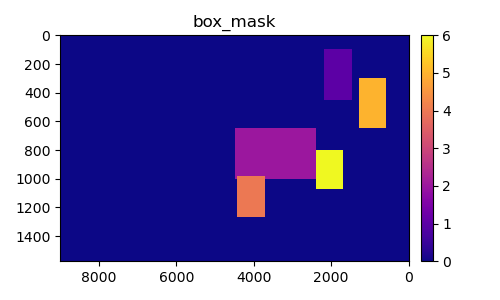

In [11]:
plt.figure(figsize=(5,3),tight_layout=True)
plt.imshow(box_mask,aspect='auto',interpolation='none')
plt.colorbar(pad=0.03); plt.set_cmap('plasma')
plt.xlim(9000,0); plt.ylim(1575,0)
plt.title('box_mask')
plt.show()

In [13]:
# make a mask for each focus area 
A_NVG_mask = np.where(box_mask==1,NVG_mask,0)
B_NVG_mask = np.where(box_mask==5,NVG_mask,0)
C_NVG_mask = np.where(box_mask==2,NVG_mask,0)
D_NVG_mask = np.where(box_mask==6,NVG_mask,0)
E_NVG_mask = np.where(box_mask==4,NVG_mask,0)

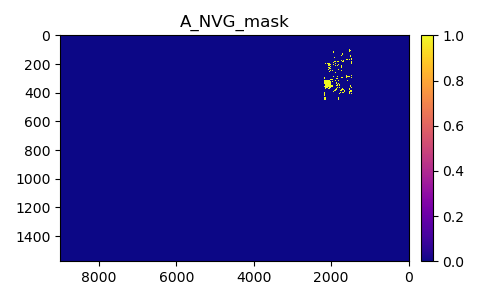

In [15]:
# Plot masks to make sure we are only considering the NVG pixels in each focus area. 
plt.figure(figsize=(5,3),tight_layout=True)
plt.imshow(A_NVG_mask,aspect='auto',interpolation='none')
plt.colorbar(pad=0.03); plt.set_cmap('plasma')
plt.xlim(9000,0); plt.ylim(1575,0)
plt.title('A_NVG_mask')
plt.show()

# plt.figure(figsize=(5,3),tight_layout=True)
# plt.imshow(B_NVG_mask,aspect='auto',interpolation='none')
# plt.colorbar(pad=0.03); plt.set_cmap('plasma')
# plt.xlim(9000,0); plt.ylim(1575,0)
# plt.title('B_NVG_mask')
# plt.show()

# plt.figure(figsize=(5,3),tight_layout=True)
# plt.imshow(C_NVG_mask,aspect='auto',interpolation='none')
# plt.colorbar(pad=0.03); plt.set_cmap('plasma')
# plt.xlim(9000,0); plt.ylim(1575,0)
# plt.title('C_NVG_mask')
# plt.show()

# plt.figure(figsize=(5,3),tight_layout=True)
# plt.imshow(D_NVG_mask,aspect='auto',interpolation='none')
# plt.colorbar(pad=0.03); plt.set_cmap('plasma')
# plt.xlim(9000,0); plt.ylim(1575,0)
# plt.title('D_NVG_mask')
# plt.show()

# plt.figure(figsize=(5,3),tight_layout=True)
# plt.imshow(E_NVG_mask,aspect='auto',interpolation='none')
# plt.colorbar(pad=0.03); plt.set_cmap('plasma')
# plt.xlim(9000,0); plt.ylim(1575,0)
# plt.title('E_NVG_mask')
# plt.show()

In [16]:
# make a function that ingests a mask and calculates the %NVG pixels captured at a series of coherence thresholds
# for individual focus areas

def grab_for_thresholds_area(mask,zoom_in_select):

    num_road_pixels = sum(mask) 

    coh_threshold2_pt1 = np.linspace(0.2,0.7, num=11, endpoint = True)
    coh_threshold2_pt2 = np.linspace(0.7,1, num=12, endpoint = False)
    coh_threshold = np.concatenate((coh_threshold2_pt1,coh_threshold2_pt2))

    m1_avg_road_masked = np.where(mask==1,coh_avg_m1,np.nan)
    m3_avg_road_masked = np.where(mask==1,coh_avg_m2,np.nan)

    tot_pix_in_area = np.nansum(np.where(box_mask==zoom_in_select,1,np.nan))

    #generate the mask for each zoom in:
    coh1_hist_masked = np.where(box_mask == zoom_in_select,coh_avg_m1,np.nan)
    coh3_hist_masked = np.where(box_mask == zoom_in_select,coh_avg_m2,np.nan)

    coh1_hist_road_masked = np.where(box_mask == zoom_in_select,m1_avg_road_masked,np.nan)
    coh3_hist_road_masked = np.where(box_mask == zoom_in_select,m3_avg_road_masked,np.nan)

    percent_captured_coh1 = np.zeros(len(coh_threshold),'float')
    percent_captured_coh3 = np.zeros(len(coh_threshold),'float')
    total_coh1 = np.zeros(len(coh_threshold),'float')*np.nan
    total_coh3 = np.zeros(len(coh_threshold),'float')*np.nan

    #determine % of road pixels captured at each coh threshold
    for c in range (len(coh_threshold)):
        #print('Coh threshold: '+str(coh_threshold[c]))
        #number of pixels in each coherence image
        coh1_c_masked = np.where(coh1_hist_masked >= coh_threshold[c], 1, np.nan)
        total_coh1[c] = np.nansum(coh1_c_masked)

        coh3_c_masked = np.where(coh3_hist_masked >= coh_threshold[c], 1, np.nan)
        total_coh3[c] = np.nansum(coh3_c_masked)

        #number of road pixels captured (in coh image masked by roads)
        road_c_masked_1 = np.where(coh1_hist_road_masked >= coh_threshold[c], 1, np.nan)
        total_road_coh1 = np.nansum(road_c_masked_1)

        road_c_masked_3 = np.where(coh3_hist_road_masked >= coh_threshold[c], 1, np.nan)
        total_road_coh3 = np.nansum(road_c_masked_3)

        #calculate % captured
        if total_coh1[c] > 0:
            percent_captured_coh1[c] = (total_road_coh1/total_coh1[c])*100
            # print('Total numerator: '+str(total_road_coh1))
            # print('Total denominator: '+str(total_coh1))
        else:
            percent_captured_coh1[c] = 0
            # print('No pixels with that coh.')

        if total_coh3[c] > 0:
            percent_captured_coh3[c] = (total_road_coh3/total_coh3[c])*100
            # print('Total numerator: '+str(total_road_coh3))
            # print('Total denominator: '+str(total_coh3))
        else:
            percent_captured_coh3[c] = 0
            # print('No pixels with that coh.')
    return percent_captured_coh1, percent_captured_coh3, total_coh1, total_coh3, tot_pix_in_area


In [17]:
percent_capt_coh1_A, percent_capt_coh2_A, total_coh1_A, total_coh2_A, tot_A = grab_for_thresholds_area(A_NVG_mask,1)
percent_capt_coh1_B, percent_capt_coh2_B, total_coh1_B, total_coh2_B, tot_B = grab_for_thresholds_area(B_NVG_mask,5)
percent_capt_coh1_C, percent_capt_coh2_C, total_coh1_C, total_coh2_C, tot_C = grab_for_thresholds_area(C_NVG_mask,2)
percent_capt_coh1_D, percent_capt_coh2_D, total_coh1_D, total_coh2_D, tot_D = grab_for_thresholds_area(D_NVG_mask,6)
percent_capt_coh1_E, percent_capt_coh2_E, total_coh1_E, total_coh2_E, tot_E = grab_for_thresholds_area(E_NVG_mask,4)

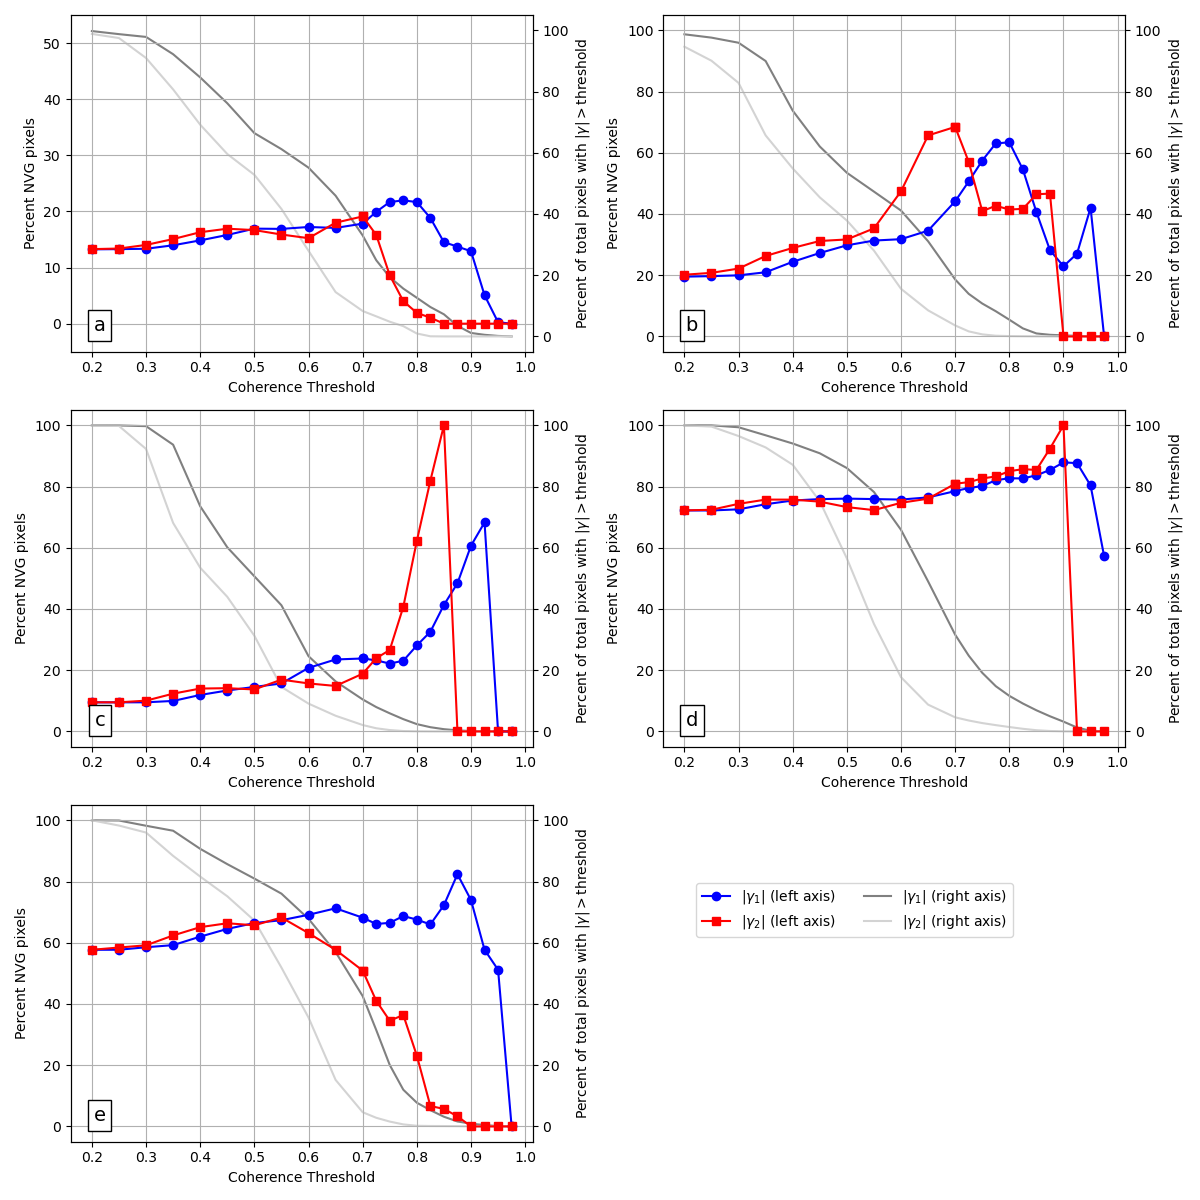

In [18]:
# This is Figure 17.
label_x = 0.075
label_y = 0.05
props = dict(boxstyle='square',facecolor='white',edgecolor='black')
twinx_ylabel = 'Percent of total pixels with $|\gamma|>$threshold'
ylabel = 'Percent NVG pixels'

fig, axs = plt.subplots(3,2,figsize=(12,12),tight_layout=True)
ax = axs[0,0]
ax.plot(coh_threshold,percent_capt_coh1_A,'b-o',label='$|\gamma_{1}|$ (left axis)')
ax.plot(coh_threshold,percent_capt_coh2_A,'r-s',label='$|\gamma_{2}|$ (left axis)')
ax.set_xlabel('Coherence Threshold')
ax.set_ylabel(ylabel)  
ax.grid()  
ax.set_ylim(-5,55)
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.set_facecolor('none')
ax1 = ax.twinx()
ax1.plot(coh_threshold,total_coh1_A/tot_A*100,'gray',linestyle='-',label='$|\gamma_{1}|$ (right axis)')
ax1.plot(coh_threshold,total_coh2_A/tot_A*100,'lightgray',linestyle='-',label='$|\gamma_{2}|$ (right axis)')
ax1.set_ylabel(twinx_ylabel)
ax1.set_zorder(ax.get_zorder() - 1)
ax1.set_ylim(-5,105)
# ax1.legend(loc='upper center')

ax = axs[0,1]
ax.plot(coh_threshold,percent_capt_coh1_B,'b-o')
ax.plot(coh_threshold,percent_capt_coh2_B,'r-s')
ax.set_xlabel('Coherence Threshold')
ax.set_ylabel(ylabel)  
ax.grid() 
ax.set_ylim(-5,105)
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.set_facecolor('none')
ax1 = ax.twinx()
ax1.plot(coh_threshold,total_coh1_B/tot_B*100,'gray',linestyle='-')
ax1.plot(coh_threshold,total_coh2_B/tot_B*100,'lightgray',linestyle='-')
ax1.set_ylabel(twinx_ylabel)
ax1.set_zorder(ax.get_zorder() - 1)
# ax1.legend(loc='upper center')
ax1.set_ylim(-5,105)

ax = axs[1,0]
ax.plot(coh_threshold,percent_capt_coh1_C,'b-o')
ax.plot(coh_threshold,percent_capt_coh2_C,'r-s')
ax.set_xlabel('Coherence Threshold')
ax.set_ylabel(ylabel)  
ax.grid() 
ax.set_ylim(-5,105)
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.set_facecolor('none')
ax1 = ax.twinx()
ax1.plot(coh_threshold,total_coh1_C/tot_C*100,'gray',linestyle='-')
ax1.plot(coh_threshold,total_coh2_C/tot_C*100,'lightgray',linestyle='-')
ax1.set_ylabel(twinx_ylabel)
ax1.set_zorder(ax.get_zorder() - 1)
# ax1.legend(loc='upper center')
ax1.set_ylim(-5,105)

ax = axs[1,1]
ax.plot(coh_threshold,percent_capt_coh1_D,'b-o')
ax.plot(coh_threshold,percent_capt_coh2_D,'r-s')
ax.set_xlabel('Coherence Threshold')
ax.set_ylabel(ylabel)  
ax.grid() 
ax.set_ylim(-5,105)
# ax.legend(loc='lower center')
ax.text(label_x, label_y, 'd', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.set_facecolor('none')
ax1 = ax.twinx()
ax1.plot(coh_threshold,total_coh1_D/tot_D*100,'gray',linestyle='-')
ax1.plot(coh_threshold,total_coh2_D/tot_D*100,'lightgray',linestyle='-')
ax1.set_ylabel(twinx_ylabel)
ax1.set_zorder(ax.get_zorder() - 1)
# ax1.legend(loc='upper center')
ax1.set_ylim(-5,105)

ax = axs[2,0]
ax.plot(coh_threshold,percent_capt_coh1_E,'b-o')
ax.plot(coh_threshold,percent_capt_coh2_E,'r-s')
ax.set_xlabel('Coherence Threshold')
ax.set_ylabel(ylabel)  
ax.grid() 
ax.set_ylim(-5,105)
ax.text(label_x, label_y, 'e', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.set_facecolor('none')
ax1 = ax.twinx()
ax1.plot(coh_threshold,total_coh1_E/tot_E*100,'gray',linestyle='-')
ax1.plot(coh_threshold,total_coh2_E/tot_E*100,'lightgray',linestyle='-')
ax1.set_ylabel(twinx_ylabel)
ax1.set_zorder(ax.get_zorder() - 1)
ax1.set_ylim(-5,105)

ax = axs[2,1]
ax.axis('off')

fig.legend(bbox_to_anchor=(0.85,0.27),ncols=2)

plt.show()
#plt.savefig('NVGs_captured_by_area.png',transparent=True,bbox_inches='tight',dpi=500)